## testing PCR images with fixed setters

In [1]:
# from grpc4bmi.bmi_client_singularity import BmiClientSingularity

# model = BmiClientSingularity('/home/avandervee3/pcr_setters_fixed.sif', work_dir='/tmp')
# print(model.get_component_name())
# del model

In [2]:
import matplotlib.pyplot as plt
from cartopy import crs
from cartopy import feature as cfeature
from rich import print
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import datetime
from ipywidgets import IntProgress
from IPython.display import display
import fiona
import shapely.geometry
from pyproj import Geod

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage

import fiona
import shapely.geometry
from pyproj import Geod
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:
# Chatly_station_latitude = 42.34332908492399  # Amu Darya near Chatly
# Chatly_station_longitude = 59.627516175820965 

Chatly_station_latitude = 42.34332908492399-0.5 # Amu Darya near Chatly
Chatly_station_longitude = 59.627516175820965+0.9    # Through trial and error, to get modelled discharge closer to observed

Kerki_station_latitude = 37.8396310038444 #Amu Darya near Kerki
Kerki_station_longitude = 65.23703868931334

#Tyumen_station_latitude = 44.01445789449254 # Syr Darya near Tyumen, google maps
#Tyumen_station_longitude = 67.02866313732494

#Tyumen_station_latitude = 44.05 # Syr Darya near Tyumen, GRDC coords
#Tyumen_station_longitude = 67.05

Tyumen_station_latitude = 44.05-0.1 # Syr Darya near Tyumen, through trial and error
Tyumen_station_longitude = 67.05

Kazalinsk_station_latitude = 45.739988222442456, #Syr Darya near Kazalinsk
Kazalinsk_station_longitude = 62.115993992559744

Dushanbe_station_latitude = 38.76042
Dushanbe_staion_longitude = 68.81458



In [4]:
# # set start and end date of the experiment, overwrites .ini settings
# experiment_start_date = "2010-01-01T00:00:00Z"
# #experiment_end_date = "1992-12-31T00:00:00Z" #was 1995-12-31T00:00:00Z, shorter for testing
# #experiment_end_date = "1990-02-28T00:00:00Z" #2 months, for testing
# experiment_end_date = "2010-03-31T00:00:00Z" #2 months, for testing

# set start and end date of the experiment, overwrites .ini settings
experiment_start_date = "1970-01-01T00:00:00Z"
#experiment_end_date = "1992-12-31T00:00:00Z" #was 1995-12-31T00:00:00Z, shorter for testing
#experiment_end_date = "1990-02-28T00:00:00Z" #2 months, for testing
experiment_end_date = "1970-01-28T00:00:00Z" #2 months, for testing

In [5]:


pcr_glob_directory = Path("/data/shared/parameter-sets/pcrglobwb_global")  #GlobalOption uit .ini

prepared_PCRGlob_forcing = (
    Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/forcing_7071")
    / "AralSeaBasin"
    / "pcrglobwb"
    / "work/diagnostic/script"
)##MeteoOptions uit .ini

prepared_PCRGlob_forcing_CMIP = (
    Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Comparison/forcing_CMIP_5570")
    / "AralSeaBasin"
    / "CMIP6" / "historic"/"PCRGlobWB"
    / "work/diagnostic/script"
)##MeteoOptions uit .ini



In [6]:


# parameter_set_cmip = ewatercycle.parameter_sets.ParameterSet(
#     name="custom_parameter_set",
#     directory=pcr_glob_directory,
#     config= "Reference_05min_agri_debug_paths.ini",
#     target_model="pcrglobwb",
#     supported_model_versions={"unknown"},
# )

parameter_set_cmip = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config= "Reference_05min_meteo_from_drive.ini",
    target_model="pcrglobwb",
    supported_model_versions={"8dec"},
)


# parameter_set_cmip_no_agri = ewatercycle.parameter_sets.ParameterSet(
#     name="custom_parameter_set",
#     directory=pcr_glob_directory,
#     config= Path.cwd() / "Reference_05min_no_agri.ini",
#     target_model="pcrglobwb",
#     supported_model_versions={"fixed"},
# )



In [7]:
forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_PCRGlob_forcing,
)




print(forcing)

PCRGlobWBForcing(
    start_time='1970-01-01T00:00:00Z',
    end_time='1971-12-31T00:00:00Z',
    directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/Test_Aral/forcing_7071/AralSeaBasin/pcrglobwb/work/diagnostic/script'),
    shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_pro
gress/Test_Aral/forcing_7071/AralSeaBasin/pcrglobwb/work/diagnostic/script/AralSeaBasin.shp'),
    filenames={},
    precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1970-1971_AralSeaBasin.nc',
    temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1970-1971_AralSeaBasin.nc'
)

In [8]:
my_image = ContainerImage('/home/avandervee3/ewatercycle-pcr_8dec.sif')
my_image.version

'8dec'

In [9]:

# from grpc4bmi.bmi_grpc_client import BmiClient
# import grpc
# import pandas as pd
# from datetime import datetime
# from ipywidgets import IntProgress
# from IPython.display import display

# # Connect to the already running container server
# client = BmiClient(grpc.insecure_channel("localhost:55555"))

# # Initialize model
# client.initialize(parameter_set=parameter_set_cmip,
#     forcing=forcing,)  # or equivalent input

# # Convert ISO 8601 strings to datetime
# start_time = datetime.strptime(experiment_start_date, '%Y-%m-%dT%H:%M:%SZ')
# end_time = datetime.strptime(experiment_end_date, '%Y-%m-%dT%H:%M:%SZ')
# number_of_days = (end_time - start_time).days

# # Prepare timeseries DataFrame
# time_index = pd.date_range(start=experiment_start_date, end=experiment_end_date)
# Stations_timeseries = pd.DataFrame(
#     index=pd.Index(time_index, name="time"),
#     columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk", "Dushanbe"]
# )

# # Progress bar
# f = IntProgress(min=0, max=number_of_days)
# display(f)

# # Simulation loop
# while client.get_current_time() < client.get_end_time():
#     client.update()

#     # Example: discharge at stations
#     Stations_timeseries.loc[pd.Timestamp(client.get_current_time()), "Chatly"] = client.get_value_at_coords(
#         "discharge", lat=[Chatly_station_latitude], lon=[Chatly_station_longitude]
#     )[0]

#     Stations_timeseries.loc[pd.Timestamp(client.get_current_time()), "Kerki"] = client.get_value_at_coords(
#         "discharge", lat=[Kerki_station_latitude], lon=[Kerki_station_longitude]
#     )[0]

#     # ... repeat for other stations

#     f.value += 1

# client.finalize()
# print("Model run finished!")


In [10]:
reference = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_cmip,
    forcing=forcing,
    bmi_image=my_image
)

print(reference)

PCRGlobWB(
    parameter_set=ParameterSet(
        name='custom_parameter_set',
        directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'),
        config=PosixPath('Reference_05min_meteo_from_drive.ini'),
        doi='N/A',
        target_model='pcrglobwb',
        supported_model_versions={'8dec'},
        downloader=None
    ),
    forcing=PCRGlobWBForcing(
        start_time='1970-01-01T00:00:00Z',
        end_time='1971-12-31T00:00:00Z',
        directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/wor
k_in_progress/Test_Aral/forcing_7071/AralSeaBasin/pcrglobwb/work/diagnostic/script'),
        shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/Test_Aral/forcing_7071/AralSeaBasin/pcrglobwb/work/diagnostic/script/AralSeaBasin.shp'),
        filenames={},
        precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1970-1971_AralSeaBasin.nc',
        temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1970-1971_AralSeaBasin.nc'
    )
)

In [11]:
reference_config, reference_dir = reference.setup(
    start_time = experiment_start_date,
    end_time = experiment_end_date,
    max_spinups_in_years=0
)
reference_config, reference_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260108_114823/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260108_114823')

In [12]:
from grpc4bmi.bmi_client_singularity import BmiClientSingularity

model = BmiClientSingularity(
    image="/home/avandervee3/ewatercycle-pcr_8dec.sif",
    work_dir="/tmp",
)

print(model.get_component_name())
del model   # shut down container + server

pcrglobwb

In [13]:
# from grpc4bmi.bmi_grpc_client import BmiClient
# import grpc

# client = BmiClient(grpc.insecure_channel("localhost:55555"))

# print(client.get_component_name())

# reference = ewatercycle.models.PCRGlobWB(
#     parameter_set=parameter_set_cmip,
#     forcing=forcing,
#     bmi_image=my_image
# )

# print(reference)

# reference_config, reference_dir = reference.setup(
#     start_time = experiment_start_date,
#     end_time = experiment_end_date,
#     max_spinups_in_years=0
# )
# reference_config, reference_dir

# print(reference.parameters)

# refence_para = reference.parameters

# # Convert ISO 8601 strings to datetime objects
# start_time = datetime.strptime(experiment_start_date, '%Y-%m-%dT%H:%M:%SZ')
# end_time = datetime.strptime(experiment_end_date, '%Y-%m-%dT%H:%M:%SZ')

# # Calculate the number of days for the progression bar
# delta = end_time - start_time
# number_of_days = delta.days
# print(f"Number of days to model: {number_of_days}")

# time = pd.date_range(reference.start_time_as_isostr, reference.end_time_as_isostr)
# # timeseries = pd.DataFrame(
# #     index=pd.Index(time, name="time"), columns=["reference", "experiment1", "experiment2"]
# # )
# # timeseries.head()

# Stations_timeseries = pd.DataFrame(
#     index=pd.Index(time, name="time"), columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk", "Dushanbe"]
# )
# Stations_timeseries.head()

# Stations_timeseries_experiment_no_agri = Stations_timeseries.copy();
# Stations_timeseries_experiment_RoutingWave = Stations_timeseries.copy();

# # Progress bar, since this can take a while
# f = IntProgress(min=0, max=number_of_days) # instantiate the bar
# display(f) # display the bar

# while reference.time < reference.end_time:

#     reference.update()

#     # Track discharge at station location
#     discharge_at_Chatly = reference.get_value_at_coords(
#         "discharge", lat=[Chatly_station_latitude], lon=[Chatly_station_longitude]
#     )
#     time = reference.time_as_isostr
#     Stations_timeseries.loc[time, "Chatly"] = discharge_at_Chatly[0]

#      # Track discharge at station location Kerki
#     discharge_at_Kerki = reference.get_value_at_coords(
#         "discharge", lat=[Kerki_station_latitude], lon=[Kerki_station_longitude]
#     )
#     time = reference.time_as_isostr
#     Stations_timeseries.loc[time, "Kerki"] = discharge_at_Kerki[0]

#     # Track discharge at station Tyumen
#     discharge_at_Tyumen = reference.get_value_at_coords(
#         "discharge", lat=[Tyumen_station_latitude], lon=[Tyumen_station_longitude]
#     )
#     time = reference.time_as_isostr
#     Stations_timeseries.loc[time, "Tyumen"] = discharge_at_Tyumen[0]

#     # Track discharge at station location Karalinsk
#     discharge_at_Kazalinsk = reference.get_value_at_coords(
#         "discharge", lat=[Kazalinsk_station_latitude], lon=[Kazalinsk_station_longitude]
#     )
#     time = reference.time_as_isostr
#     Stations_timeseries.loc[time, "Kazalinsk"] = discharge_at_Kazalinsk[0]

#     # Track discharge at station location Dushanbe
#     discharge_at_Dushanbe = reference.get_value_at_coords(
#         "discharge", lat=[Dushanbe_station_latitude], lon=[Dushanbe_staion_longitude]
#     )
#     time = reference.time_as_isostr
#     Stations_timeseries.loc[time, "Dushanbe"] = discharge_at_Dushanbe[0]    


#     f.value += 1

# print("Model run finished!")

In [14]:
print(reference.parameters)

refence_para = reference.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, '%Y-%m-%dT%H:%M:%SZ')
end_time = datetime.strptime(experiment_end_date, '%Y-%m-%dT%H:%M:%SZ')

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1970-01-01T00:00:00Z'), ('end_time', '1970-01-28T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 27

In [15]:
print("Using config:", reference_config)

Using config: 
/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/explo
ration/Image_tests/pcrglobwb_20260108_114823/pcrglobwb_ewatercycle.ini

In [16]:
reference.initialize(reference_config)

In [17]:
time = pd.date_range(reference.start_time_as_isostr, reference.end_time_as_isostr)
# timeseries = pd.DataFrame(
#     index=pd.Index(time, name="time"), columns=["reference", "experiment1", "experiment2"]
# )
# timeseries.head()

In [18]:
Stations_timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk"]
)
Stations_timeseries.head()

Stations_timeseries_experiment_no_agri = Stations_timeseries.copy();
Stations_timeseries_experiment_RoutingWave = Stations_timeseries.copy();

In [19]:
# # Progress bar, since this can take a while
# f = IntProgress(min=0, max=number_of_days) # instantiate the bar
# display(f) # display the bar

# while reference.time < reference.end_time:

#     reference.update()

#     # # Track discharge at station location
#     # discharge_at_Chatly = reference.get_value_at_coords(
#     #     "discharge", lat=[Chatly_station_latitude], lon=[Chatly_station_longitude]
#     # )
#     # time = reference.time_as_isostr
#     # Stations_timeseries.loc[time, "Chatly"] = discharge_at_Chatly[0]

#     #  # Track discharge at station location Kerki
#     # discharge_at_Kerki = reference.get_value_at_coords(
#     #     "discharge", lat=[Kerki_station_latitude], lon=[Kerki_station_longitude]
#     # )
#     # time = reference.time_as_isostr
#     # Stations_timeseries.loc[time, "Kerki"] = discharge_at_Kerki[0]

#     # # Track discharge at station Tyumen
#     # discharge_at_Tyumen = reference.get_value_at_coords(
#     #     "discharge", lat=[Tyumen_station_latitude], lon=[Tyumen_station_longitude]
#     # )
#     # time = reference.time_as_isostr
#     # Stations_timeseries.loc[time, "Tyumen"] = discharge_at_Tyumen[0]

#     # # Track discharge at station location Karalinsk
#     # discharge_at_Kazalinsk = reference.get_value_at_coords(
#     #     "discharge", lat=[Kazalinsk_station_latitude], lon=[Kazalinsk_station_longitude]
#     # )
#     # time = reference.time_as_isostr
#     # Stations_timeseries.loc[time, "Kazalinsk"] = discharge_at_Kazalinsk[0]

#     # # Track discharge at station location Dushanbe
#     # discharge_at_Dushanbe = reference.get_value_at_coords(
#     #     "discharge", lat=[Dushanbe_station_latitude], lon=[Dushanbe_staion_longitude]
#     # )
#     # time = reference.time_as_isostr
#     # Stations_timeseries.loc[time, "Dushanbe"] = discharge_at_Dushanbe[0]    


#     f.value += 1

# print("Model run finished!")

In [21]:
from tqdm.notebook import tqdm

for _ in tqdm(range(number_of_days), desc="Running model"):
    
    reference.update()
    
    # # Track discharge at station locations
    # discharge_at_Chatly = reference.get_value_at_coords(
    #     "discharge", lat=[Chatly_station_latitude], lon=[Chatly_station_longitude]
    # )
    # discharge_at_Kerki = reference.get_value_at_coords(
    #     "discharge", lat=[Kerki_station_latitude], lon=[Kerki_station_longitude]
    # )
    # discharge_at_Tyumen = reference.get_value_at_coords(
    #     "discharge", lat=[Tyumen_station_latitude], lon=[Tyumen_station_longitude]
    # )
    # discharge_at_Kazalinsk = reference.get_value_at_coords(
    #     "discharge", lat=[Kazalinsk_station_latitude], lon=[Kazalinsk_station_longitude]
    # )

    # # Store values
    # time = reference.time_as_isostr
    # Stations_timeseries.loc[time, "Chatly"] = discharge_at_Chatly[0]
    # Stations_timeseries.loc[time, "Kerki"] = discharge_at_Kerki[0]
    # Stations_timeseries.loc[time, "Tyumen"] = discharge_at_Tyumen[0]
    # Stations_timeseries.loc[time, "Kazalinsk"] = discharge_at_Kazalinsk[0]

print("Model run finished!")

Running model:   0%|          | 0/27 [00:00<?, ?it/s]

Model run finished!

In [ ]:
# import xarray as xr
# ds = xr.open_dataset("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/forcing_0419/AralSeaBasin/pcrglobwb/work/diagnostic/script/pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_2004-2019_AralSeaBasin.nc")

# # Print alle time values
# print(ds.time.values)

# # Print eerste en laatste time value
# print("Start:", ds.time.values[0])
# print("End:", ds.time.values[-1])

# # Print time_bnds als die bestaat
# if "time_bnds" in ds:
#     print(ds.time_bnds.values)


In [ ]:
# import netCDF4

# # Path to your forcing file
# file_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/forcing_0419/AralSeaBasin/pcrglobwb/work/diagnostic/script/pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_2004-2019_AralSeaBasin.nc"

# # Open the netCDF file
# f = netCDF4.Dataset(file_path, mode='r')

# # Choose the variable you want to check
# varName = "pr"  # or whatever variable PCR-GLOBWB is trying to use
# var = f.variables[varName]

# # Print info
# print("Variable:", varName)
# print("Shape:", var.shape)
# print("Dimensions:", var.dimensions)

# # Example: check time index
# idx = 2557  # replace with the index you expect for 2010-01-01
# print("Time index:", idx, "Max index:", var.shape[0]-1)

# data = f.variables[varName][idx, :, :]

# # Optionally, get lat/lon for reference
# lat = f.variables['lat'][:]
# lon = f.variables['lon'][:]


# # Close the file
# f.close()

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# plt.pcolormesh(lon, lat, data, shading='auto', cmap='coolwarm')
# plt.colorbar(label='Temperature (K)')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# #plt.title(f'{varName} at index {idx}')
# plt.show()

dict_keys(['time', 'lat', 'lon', 'discharge'])

(28, 180, 252)

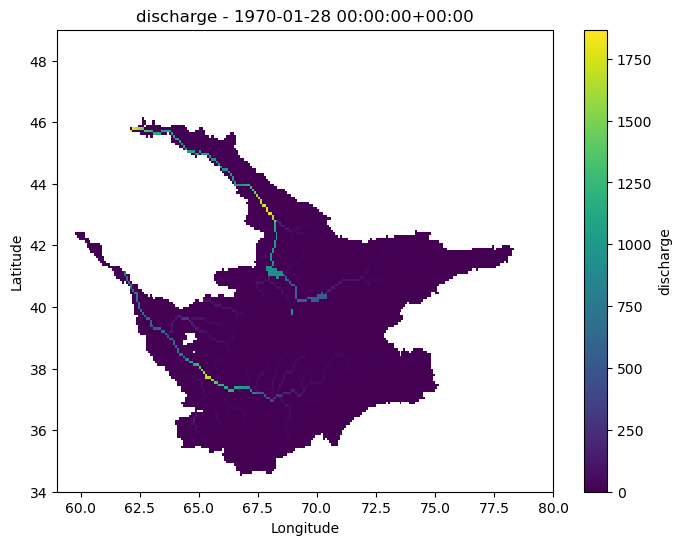

In [24]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# Path to your file
file_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260108_114823/netcdf/discharge_dailyTot_output.nc"

# Open the NetCDF file
ds = nc.Dataset(file_path)

# Inspect variables
print(ds.variables.keys())  # should show 'discharge' or similar variable + lat/lon

# Choose the variable (replace with actual variable name if different)
var_name = 'discharge'  # check exact name from keys() above
var = ds.variables[var_name]

# Check shape
print(var.shape)  # (time, lat, lon) or maybe (lat, lon, time)

# Get the last timestep
last_idx = var.shape[0] - 1  # last index
if var.ndim == 3:  # assuming (time, lat, lon)
    data_last = var[last_idx, :, :]
elif var.ndim == 2:  # sometimes already 2D
    data_last = var[:, :]
else:
    raise ValueError("Unexpected variable shape")

# Get lat/lon for plotting
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]

# Quick 2D plot
plt.figure(figsize=(8,6))
plt.pcolormesh(lon, lat, data_last, shading='auto')
plt.colorbar(label=var_name)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'{var_name} - {time[-1]}')
plt.show()


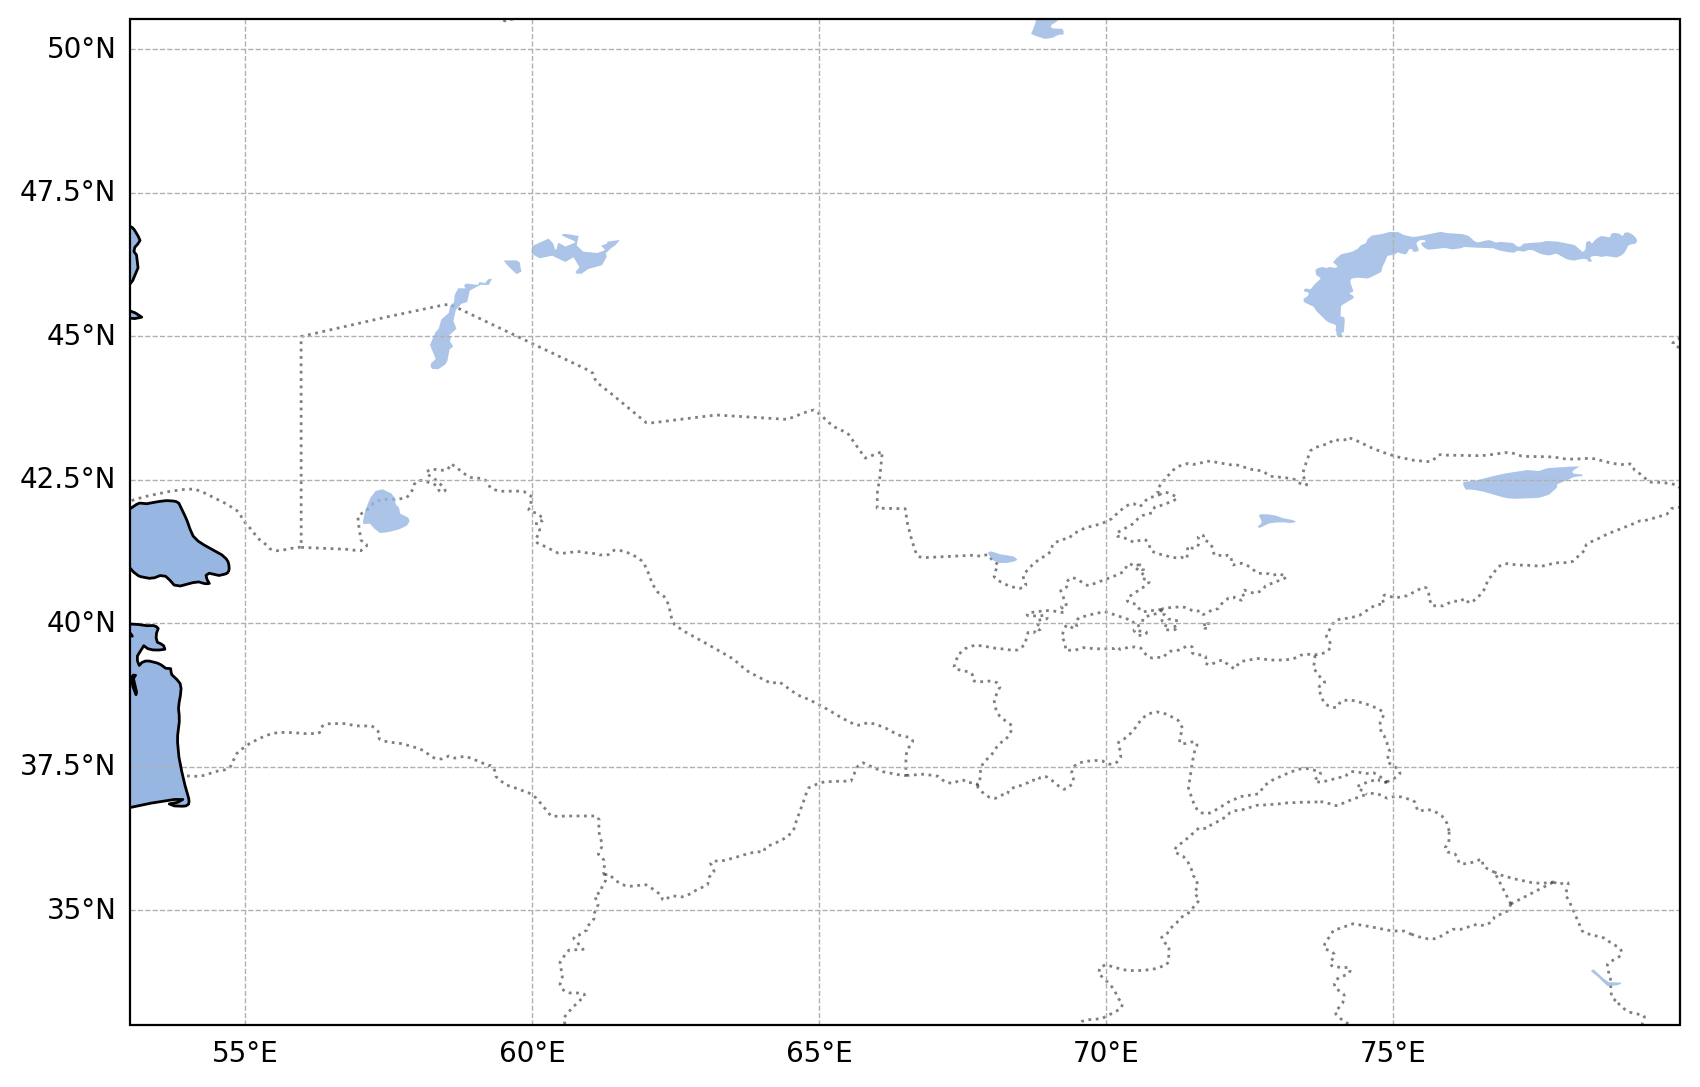

In [26]:
fig = plt.figure(figsize=(10,8), dpi=200)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())


# Coastlines and other features
ax.add_feature(cfeature.OCEAN, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':',alpha=0.5, zorder=2)
ax.add_feature(cfeature.LAKES, alpha=0.8, zorder=2)
ax.coastlines(zorder=3)

# Set map extent
ax.set_extent([53, 80, 33, 50])

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
gl.top_labels = False
gl.right_labels = False


dict_keys(['time', 'lat', 'lon', 'discharge'])

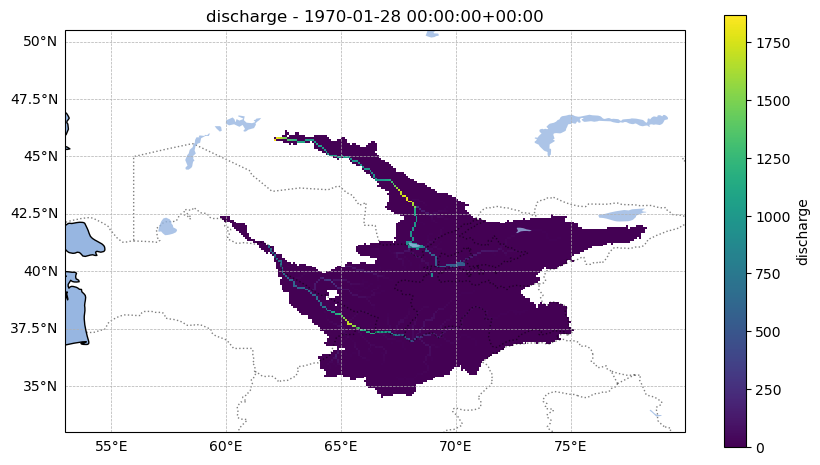

In [33]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Path to your NetCDF file
file_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260108_114823/netcdf/discharge_dailyTot_output.nc"

# Open NetCDF
ds = nc.Dataset(file_path)

# Check variable names
print(ds.variables.keys())  # e.g., 'discharge', 'lat', 'lon'

var_name = 'discharge'  # replace if different
var = ds.variables[var_name]

# Get lat/lon
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]

# Last timestep
last_idx = var.shape[0] - 1
data_last = var[last_idx, :, :]  # assuming (time, lat, lon)

# Create figure with PlateCarree projection
fig, ax = plt.subplots(figsize=(10,8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot data
pcm = ax.pcolormesh(lon, lat, data_last, shading='auto', cmap='viridis', zorder=1)

# Colorbar, shrunk to 70%
cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', label=var_name, shrink=0.7)

# Add coastlines and features
ax.add_feature(cfeature.OCEAN, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5, zorder=2)
ax.add_feature(cfeature.LAKES, alpha=0.8, zorder=2)
ax.coastlines(zorder=3)

# Set map extent [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([53, 80, 33, 50])

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)
gl.top_labels = False
gl.right_labels = False

# Optional title
ax.set_title(f'{var_name} - {time[-1]}')

plt.show()
